  Ticker        Date  Open  High   Low  Close  Adj Close     Volume
0   AAPL  2000-01-03  0.94  1.00  0.91   1.00       0.84  535796800
1   AAPL  2000-01-04  0.97  0.99  0.90   0.92       0.77  512377600
2   AAPL  2000-01-05  0.93  0.99  0.92   0.93       0.78  778321600
3   AAPL  2000-01-06  0.95  0.96  0.85   0.85       0.71  767972800
4   AAPL  2000-01-07  0.86  0.90  0.85   0.89       0.75  460734400
Dataset Shape: (514075, 8)
Input Shape: (6511, 60, 1)
Target Shape: (6511, 1)
Training Data: (5208, 60, 1)
Testing Data: (1303, 60, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 1.8449e-04 - val_loss: 7.8983e-04
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 3.6273e-05 - val_loss: 1.9230e-04
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 2.9552e-05 - val_loss: 2.3773e-04
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 2.6368e-05 - val_loss: 2.0860e-04
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 2.1496e-05 - val_loss: 1.6952e-04
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 2.4553e-05 - val_loss: 1.7555e-04
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 2.5100e-05 - val_loss: 2.4414e-04
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 1.9394e-05 - val_loss: 1.5303e-04
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 1.9582e-05 - val_loss: 1.7602e-04
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 2.5060e-05 - val_loss: 1.5352e-04
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

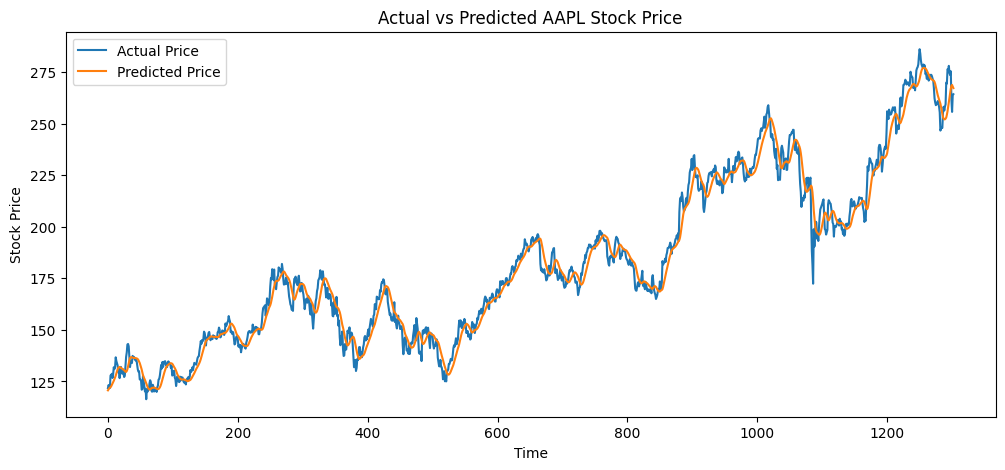

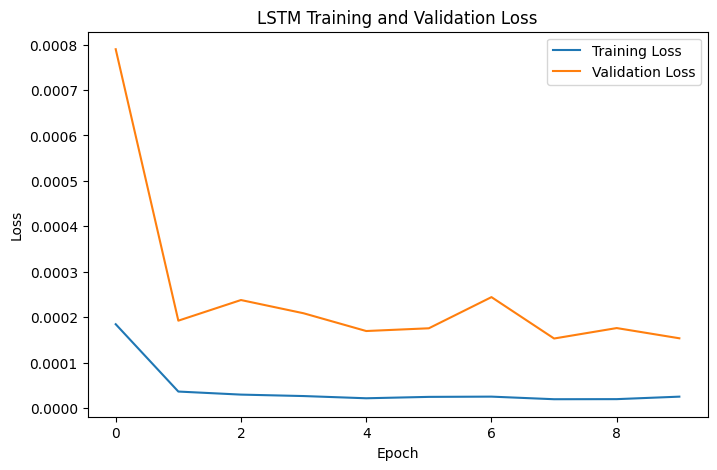

In [ ]:
# BY Vladlen Rebello | PRN: 23070521170

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Unzip dataset
with zipfile.ZipFile("/content/archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("/content/nasdaq_data")

# Load dataset
data = pd.read_csv("/content/nasdaq_data/NASDAQ100_Historical_Data.csv")

print(data.head())
print("Dataset Shape:", data.shape)

# Select one stock
stock = data[data["Ticker"] == "AAPL"].copy()

# Sort by date
stock["Date"] = pd.to_datetime(stock["Date"])
stock = stock.sort_values("Date")

# Select closing price
prices = stock[["Close"]].values

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# Create sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(prices_scaled)):
    X.append(prices_scaled[i-sequence_length:i])
    y.append(prices_scaled[i])

X = np.array(X)
y = np.array(y)

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

# Train-test split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Create LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compile model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Model summary
model.summary()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Convert predictions back to original prices
predictions = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test)

# Evaluation
mse = mean_squared_error(actual_prices, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices, predictions)

print("\nEvaluation Metrics")
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))

# Actual vs Predicted graph
plt.figure(figsize=(12, 5))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted AAPL Stock Price")
plt.legend()
plt.show()

# Training loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()